Max |vorticity| after evolution: 4.194e-13


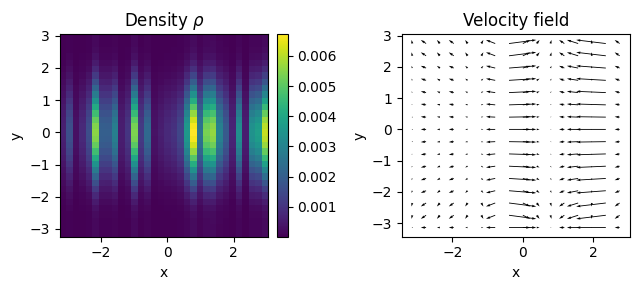

In [5]:
# Potential flow simulation on Qiskit
# Diverging flow example from 'Simulating unsteady flows on a superconducting quantum processor'
# This script builds the initial potential flow state from observables (density & velocity),
# evolves it under a kinetic Hamiltonian using Qiskit Aer, and visualizes the results.

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftfreq
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


# -------------------------------
# Quantum circuit helpers
# -------------------------------

def kinetic_operator(n: int, dt: float) -> QuantumCircuit:
    """Return the circuit implementing exp(-i ∂_xx dt /2) in Fourier space for n qubits."""
    qc = QuantumCircuit(n)
    qc.rz(-2 ** (n - 1) * dt, n - 1)
    for i in range(n):
        qc.rz(2 ** (n - i - 2) * dt, n - i - 1)
    for i in range(1, n):
        qc.cx(n - 1, n - i - 1)
        qc.rz(-2 ** (2 * n - i - 2) * dt, n - i - 1)
        qc.cx(n - 1, n - i - 1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n - i - 1, n - j - 1)
                qc.rz(2 ** (2 * n - i - j - 4) * dt, n - j - 1)
                qc.cx(n - i - 1, n - j - 1)
    return qc


def evolve(nx: int, ny: int, dt: float, initial_state: np.ndarray) -> np.ndarray:
    """One‑shot evolution of a potential flow wave‑function on an nx×ny register."""
    q_num = nx + ny  # single‑component ψ ⇒ no extra qubit

    circ = QuantumCircuit(q_num)
    circ.initialize(initial_state)
    circ.barrier()

    from qiskit.circuit.library import QFT

    # QFT blocks
    QFT_x = QFT(nx)
    QFT_y = QFT(ny)
    IQFT_x = QFT(nx).inverse()
    IQFT_y = QFT(ny).inverse()

    # Diagonal kinetic operators in k‑space
    kinetic_x = kinetic_operator(nx, dt)
    kinetic_y = kinetic_operator(ny, dt)

    # x, y Fourier → apply phase → inverse
    circ.append(QFT_x, range(nx))
    circ.append(QFT_y, range(nx, nx + ny))
    circ.barrier()
    circ.append(kinetic_x, range(nx))
    circ.append(kinetic_y, range(nx, nx + ny))
    circ.barrier()
    circ.append(IQFT_x, range(nx))
    circ.append(IQFT_y, range(nx, nx + ny))

    circ.save_state()
    simulator = AerSimulator(method="statevector")
    circ = transpile(circ, simulator)
    result = simulator.run(circ).result()
    statevector = np.asarray(result.data(0)["statevector"], dtype=np.complex128)
    return statevector


# -------------------------------
# Classical field helpers
# -------------------------------

def build_psi_from_obs(rho0: np.ndarray, ux0: np.ndarray, uy0: np.ndarray) -> np.ndarray:
    """Construct single‑component ψ0 = √ρ · e^{iφ} from (ρ, u_x, u_y)."""
    N = rho0.shape[0]
    kx = fftfreq(N) * N
    ky = fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky)

    Ux_k = fft2(ux0)
    Uy_k = fft2(uy0)

    denom = KX ** 2 + KY ** 2
    denom[0, 0] = 1.0  # avoid 0/0
    phi_k = -1j * (KX * Ux_k + KY * Uy_k) / denom
    phi_k[0, 0] = 0.0  # gauge: set mean φ to 0

    phi0 = np.real(ifft2(phi_k))
    psi0 = np.sqrt(rho0) * np.exp(1j * phi0)
    psi0 /= np.linalg.norm(psi0)  # global normalization for Qiskit
    return psi0


def compute_fluid_quantities(psi: np.ndarray, N: int):
    kx = fftfreq(N) * N
    ky = fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky)

    psi_spec = fft2(psi)
    dpsi_x = ifft2(1j * KX * psi_spec)
    dpsi_y = ifft2(1j * KY * psi_spec)

    rho = np.abs(psi) ** 2
    ux = (np.real(psi) * np.imag(dpsi_x) - np.imag(psi) * np.real(dpsi_x)) / rho
    uy = (np.real(psi) * np.imag(dpsi_y) - np.imag(psi) * np.real(dpsi_y)) / rho

    vor = np.real(ifft2(1j * KX * fft2(uy) - 1j * KY * fft2(ux)))
    return rho, ux, uy, vor


# -------------------------------
# Main routine
# -------------------------------
if __name__ == "__main__":
    # Grid / register size (N = 2^n)
    N = 2 ** 5
    nx = ny = 5
    dt = 1.0  # one‑shot time step

    # Physical grid
    x = np.linspace(-np.pi, np.pi, N, endpoint=False)
    y = np.linspace(-np.pi, np.pi, N, endpoint=False)
    X, Y = np.meshgrid(x, y)

    # Diverging flow initial observables (Supplementary Eq. S15)
    rho0 = np.exp(-Y ** 2)   # density profile
    ux0 = np.exp(X)          # velocity x‑component
    uy0 = np.zeros_like(X)   # velocity y‑component

    # Build initial wave‑function & flatten
    psi0 = build_psi_from_obs(rho0, ux0, uy0)
    initial_state = psi0.reshape(-1).astype(np.complex128)

    # Evolve
    statevector_t = evolve(nx, ny, dt, initial_state)
    psi_t = statevector_t.reshape(N, N)

    # Analyse fields
    rho, ux, uy, vor = compute_fluid_quantities(psi_t, N)
    print(f"Max |vorticity| after evolution: {np.max(np.abs(vor)):.3e}")

    # Plot density and velocity
    fig, ax = plt.subplots(1, 2, figsize=(6.5, 3))
    pcm = ax[0].pcolormesh(X, Y, rho, shading="auto")
    fig.colorbar(pcm, ax=ax[0], fraction=0.046, pad=0.04)
    ax[0].set_title("Density $\\rho$")

    skip = 2
    ax[1].quiver(X[::skip, ::skip], Y[::skip, ::skip], ux[::skip, ::skip], uy[::skip, ::skip])
    ax[1].set_title("Velocity field")
    for a in ax:
        a.set_xlabel("x"); a.set_ylabel("y")
    plt.tight_layout()
    plt.show()
